# Introdução 

## Contexto

O serviço de telefonia virtual CallMeMaybe está desenvolvendo uma nova funcionalidade que permitirá aos supervisores **identificar operadores menos eficientes**.

Os clientes da empresa são **organizações que precisam gerenciar grandes volumes de chamadas** — tanto recebidas quanto realizadas por diversos operadores.

De acordo com as regras de negócio, um operador é considerado **ineficiente** se:

- Possui **muitas chamadas recebidas perdidas** (internas ou externas);
- Apresenta **tempo de espera prolongado** nas chamadas recebidas;
- E, no caso de operadores responsáveis por chamadas de saída, realiza **poucas chamadas ativas**.

## Dados

O dataset compactado **`telecom_dataset_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID da conta do cliente
- **`date`**: data em que as estatísticas foram coletadas
- **`direction`**: “direção” da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**)
- **`internal`**: indica se a chamada foi **interna** (entre operadores de um mesmo cliente)
- **`operator_id`**: identificador do operador
- **`is_missed_call`**: indica se foi uma **chamada perdida**
- **`calls_count`**: número de chamadas
- **`call_duration`**: duração da chamada (sem incluir o tempo de espera)
- **`total_call_duration`**: duração total da chamada (incluindo o tempo de espera)

O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

## Objetivo 

O objetivo da análise será averiguar a eficiência dos operadores de acordo com as orientações base fornecidas pela companhia para oferecer ao fim uma avaliação confiável para tomada de decisão.

# Setup e Dados

## Ambiente

### Importação bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import warnings 
import stats as st 
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu


### Configurações Globais

In [3]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### Carregamento de dados

In [ ]:
telecom = pd.read_csv('../datasets/telecom_dataset_new.csv')

In [ ]:
clients = pd.read_csv('../datasets/telecom_clients.csv')

## Pré Processamento 

### Primeiras impressões

In [6]:
# primeira visualização
telecom.head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


In [7]:
# descoberta informações sobre os dados  
telecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


In [8]:
# descoberta características dos dados
telecom.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,53902.00,167295.34,598.88,166377.00,166782.00,167162.00,167819.00,168606.00
operator_id,45730.00,916535.99,21254.12,879896.00,900788.00,913938.00,937708.00,973286.00
calls_count,53902.00,16.45,62.92,1.00,1.00,4.00,12.00,4817.00
call_duration,53902.00,866.68,3731.79,0.00,0.00,38.00,572.00,144395.00
total_call_duration,53902.00,1157.13,4403.47,0.00,47.00,210.00,902.00,166155.00


O dataset *telecom* possui a nomenclatura de suas colunas dentro do padrão snake_case, encontram-se valores ausentes nas colunas *internal* e *operator_id* e seria mais adequado mudança no tipo de dado em colunas como *date* e *operator_id*.

In [9]:
# primeira visualização
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [10]:
# descoberta informações sobre os dados  
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


In [11]:
# descoberta características dos dados  
clients.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,732.00,167431.93,633.81,166373.00,166900.75,167432.00,167973.00,168606.00


O dataset *clients* possui a nomenclatura de suas colunas dentro do padrão snake_case, não encontram-se valores ausentes e seria mais adequado mudança no tipo de dado na coluna *date_start*.  

### Valores duplicados

In [12]:
# # descoberta quantidade de registros duplicados dataset clients
clients.duplicated().sum()

np.int64(0)

In [13]:
# descoberta quantidade de registros duplicados dataset telecom
telecom.duplicated().sum()

np.int64(4900)

In [14]:
# visualização de registros duplicados
telecom[telecom.duplicated()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.00,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.00,False,11,1413,1473
...,...,...,...,...,...,...,...,...,...
53869,168601,2019-11-25 00:00:00+03:00,in,False,952914.00,False,7,1229,1282
53874,168601,2019-11-26 00:00:00+03:00,in,False,952914.00,False,4,539,562
53875,168601,2019-11-26 00:00:00+03:00,in,False,NaN,True,3,0,35
53885,168603,2019-11-20 00:00:00+03:00,out,False,959118.00,True,3,0,89


In [15]:
# eliminação registros duplicados
telecom = telecom.drop_duplicates().reset_index(drop=True)

4900 registros (~9% dos dados) foram deletados por se tratarem de duplicatas. Não aparenta possuir um padrão claro de repetição.

### Valores nulos

In [16]:
# descoberta quantidade registros ausentes dataset clients
clients.isnull().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [17]:
# descoberta quantidade registros ausentes dataset telecom
telecom.isnull().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [18]:
# visualização de registros duplicados
telecom[telecom['internal'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
917,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
996,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1705,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1761,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.00,False,1,2,9
5645,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.00,False,1,393,423
...,...,...,...,...,...,...,...,...,...
47702,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
47819,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
47844,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
48837,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


In [19]:
# visualização de registros duplicados
telecom[telecom['operator_id'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
16,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
26,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
...,...,...,...,...,...,...,...,...,...
48978,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39
48982,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19
48990,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30
48994,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121


In [20]:
# 
telecom[telecom['operator_id'].isnull()]['is_missed_call'].value_counts()

is_missed_call
True     7343
False     113
Name: count, dtype: int64

A maioria esmagadora de valores nulos na coluna 'operator_id' possuem 'is_missed_call' == True. 

Esse fato pode ser derivado de um erro sistêmico ou chamadas que nem sequer foram atribuídas a um operador (erro sistêmico). 

In [21]:
# exclusão valores nulos
telecom = telecom.dropna()  

Cerca de 7500 registros (~15% dos dados) foram deletados por possível erro sistêmico. 

### Ajuste tipo de dado

In [22]:
# ajuste tipo de dado 'date'
telecom['date'] = pd.to_datetime(telecom['date'])

In [23]:
# ajuste fuso horário
telecom['date'] = telecom['date'].dt.tz_convert('Europe/Lisbon')

In [24]:
# ajuste date_start
clients['date_start'] = pd.to_datetime(clients['date_start'])

### Criação novas colunas

In [25]:
# criação coluna 'waiting_time'
telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']

In [26]:
# criação coluna 'month'
telecom['month'] = telecom['date'].dt.month 

In [27]:
telecom['week'] = telecom['date'].dt.isocalendar().week 

In [28]:
# criação coluna 'day'
telecom['day'] = telecom['date'].dt.day

In [29]:
# criação coluna 'week'
telecom['day_of_week'] = telecom['date'].dt.dayofweek

In [30]:
# criação coluna 'is_weekend'
telecom['is_weekend'] = telecom['day_of_week'].isin([5,6]).astype(int)

In [31]:
# criação coluna 'hour'
telecom['hour'] = telecom['date'].dt.hour

In [32]:
print(telecom['month'].nunique())
print(telecom['day'].nunique())
print(telecom['day_of_week'].nunique())
print(telecom['hour'].nunique()) 

4
31
7
2


Não será possível analisar a variação de horas, tratam-se de dados agregados diariamente.

In [33]:
telecom = telecom.drop(columns='hour')

# Análise Exploratória de Dados

### Volume mensal de chamadas

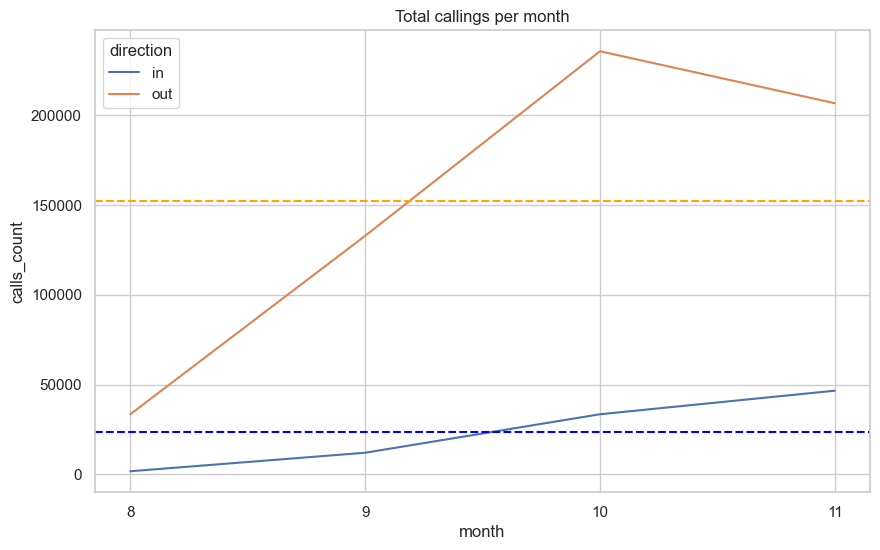

Média mensal geral de chamadas: 175521.25
Média mensal geral de chamadas outound: 152085.75
Média mensal geral de chamadas inbound: 23435.50


In [66]:
# criação de gráfico de linhas
sns.lineplot(data=telecom.groupby(['month', 'direction'])['calls_count'].sum().reset_index(), x='month', y='calls_count', hue='direction')
plt.title('Total callings per month')
plt.xticks(telecom['month'].unique())
plt.axhline(y=(telecom[telecom['direction'] == 'in']['calls_count'].sum() / telecom['month'].nunique()), color='blue', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out']['calls_count'].sum() / telecom['month'].nunique()), color='orange', linestyle='--')
plt.show()
print(f"Média mensal geral de chamadas: {telecom['calls_count'].sum() / telecom['month'].nunique():.2f}")
print(f"Média mensal geral de chamadas outound: {telecom[telecom['direction'] == 'out']['calls_count'].sum() / telecom['month'].nunique():.2f}")
print(f"Média mensal geral de chamadas inbound: {telecom[telecom['direction'] == 'in']['calls_count'].sum() / telecom['month'].nunique():.2f}")

Aumento exponencial do volume de chamadas outbound ao longo do período (~300%), enquanto para chamadas inbound seguiu um ritmo linear.

### Volume semanal de chamadas

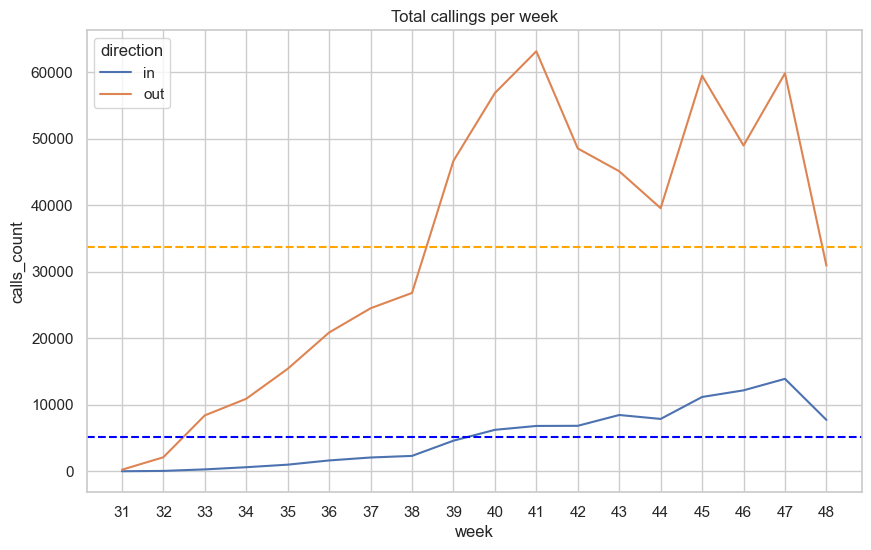

Média semanal geral de chamadas: 39004.72
Média semanal geral de chamadas outound: 33796.83
Média semanal geral de chamadas inbound: 5207.89


In [68]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['week', 'direction'])['calls_count'].sum().reset_index(), x='week', y='calls_count', hue='direction')
plt.title('Total callings per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=(telecom[telecom['direction'] == 'in']['calls_count'].sum() / telecom['week'].nunique()), color='blue', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out']['calls_count'].sum() / telecom['week'].nunique()), color='orange', linestyle='--')
plt.show()
print(f"Média semanal geral de chamadas: {telecom['calls_count'].sum() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de chamadas outound: {telecom[telecom['direction'] == 'out']['calls_count'].sum() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de chamadas inbound: {telecom[telecom['direction'] == 'in']['calls_count'].sum() / telecom['week'].nunique():.2f}")

O crescimento do volume de chamadas reafirma o padrão visto dentro do volume mensal, mas com o detalhe de que já nas últimas semanas estava acontecendo um declínio.

### Volume diário de chamadas

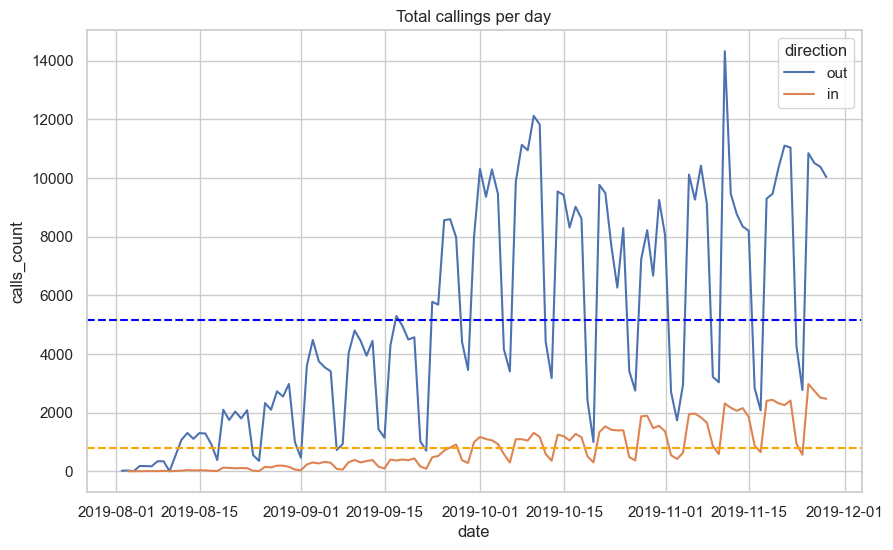

Média diária geral de chamadas: 5949.87
Média diária geral de chamadas outound: 5155.45
Média diária geral de chamadas inbound: 794.42


In [69]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['date', 'direction'])['calls_count'].sum().reset_index(), x='date', y='calls_count', hue='direction')
plt.title('Total callings per day')
plt.axhline(y=(telecom[telecom['direction'] == 'in']['calls_count'].sum() / telecom['date'].nunique()), color='orange', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out']['calls_count'].sum() / telecom['date'].nunique()), color='blue', linestyle='--')
plt.show()
print(f"Média diária geral de chamadas: {telecom['calls_count'].sum() / telecom['date'].nunique():.2f}")
print(f"Média diária geral de chamadas outound: {telecom[telecom['direction'] == 'out']['calls_count'].sum() / telecom['date'].nunique():.2f}")
print(f"Média diária geral de chamadas inbound: {telecom[telecom['direction'] == 'in']['calls_count'].sum() / telecom['date'].nunique():.2f}")

Visualização do mesmo padrão visto anteriormente, as oscilações bruscas devem-se referir aos dias de menor volume de chamadas (fins de semana).

### Proporção de chamadas por dia da semana

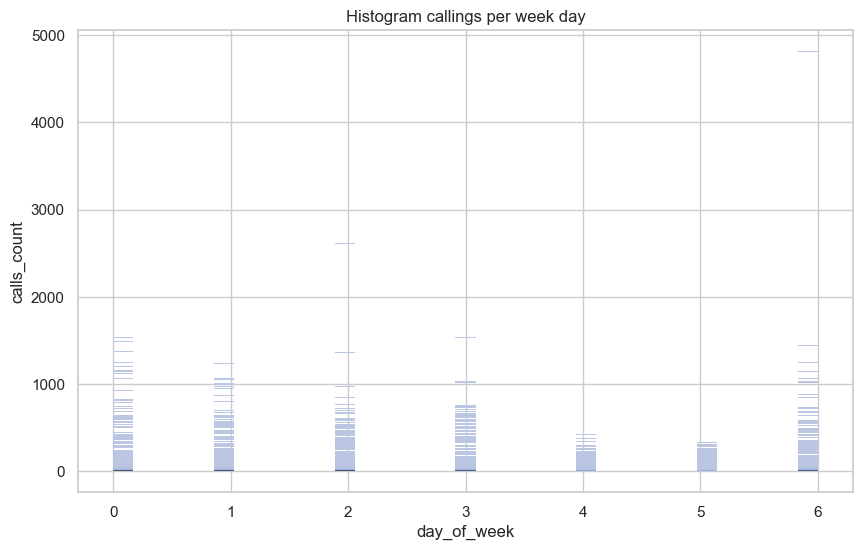

Porcentagem de chamadas no dia 6: 17.35%
Porcentagem de chamadas no dia 0: 18.76%
Porcentagem de chamadas no dia 1: 18.01%
Porcentagem de chamadas no dia 2: 18.64%
Porcentagem de chamadas no dia 3: 16.52%
Porcentagem de chamadas no dia 4: 6.24%
Porcentagem de chamadas no dia 5: 4.48%


In [91]:
# criação histplot
sns.histplot(data=telecom, x='day_of_week', y='calls_count')
plt.title('Histogram callings per week day')
plt.show()
for x in telecom['day_of_week'].unique():
    print(f"Porcentagem de chamadas no dia {x}: {(telecom[telecom['day_of_week'] == x]['calls_count'].sum() / telecom['calls_count'].sum()) * 100:.2f}%")

Sexta-feira e sábado são os dias com menores volume de chamadas.

Finais de semana representam cerca de 20% das chamadas.

### Proporção de chamadas inbound e outbound

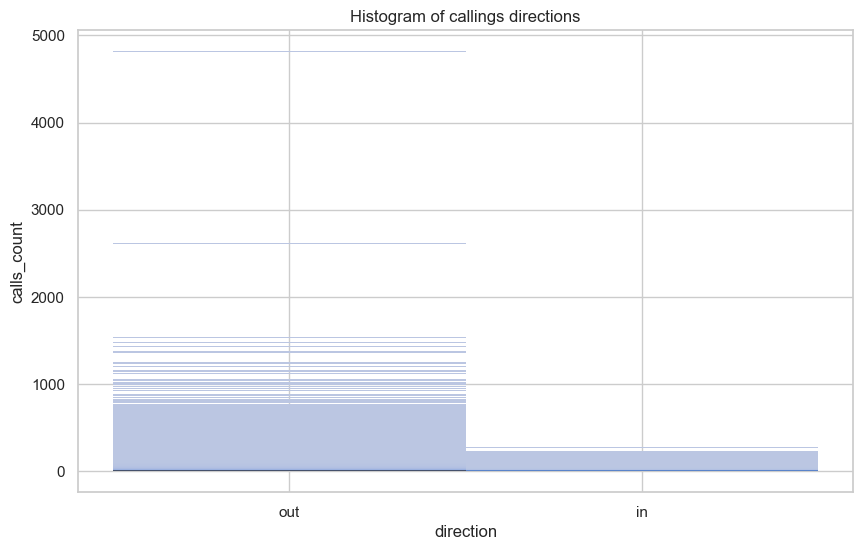

Porcentagem de chamadas outbound: 86.65%
Porcentagem de chamadas inbound: 13.35%


In [88]:
# criação histograma
sns.histplot(data=telecom, x='direction', y='calls_count')
plt.title('Histogram of callings directions')
plt.xticks(telecom['direction'].unique())
plt.show()
print(f"Porcentagem de chamadas outbound: {(telecom[telecom['direction'] == 'out']['calls_count'].sum() / telecom['calls_count'].sum()) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound: {(telecom[telecom['direction'] == 'in']['calls_count'].sum() / telecom['calls_count'].sum()) * 100:.2f}%")

Chamadas outbound representam a maioria dos dados (aproximadamente 87% x 13%).

### Proporção de chamadas internas e externas

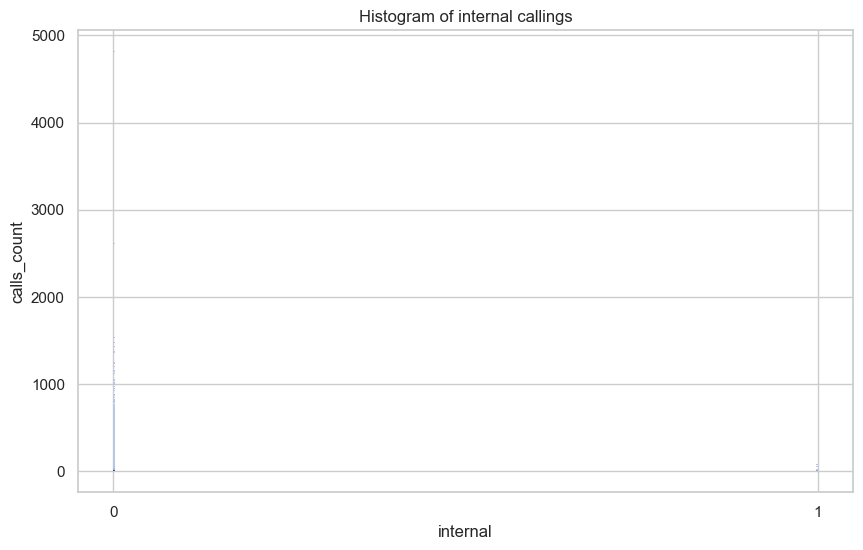

Porcentagem de chamadas externas: 98.05%
Porcentagem de chamadas internas: 1.95%


In [92]:
# criação histograma
sns.histplot(data=telecom, x='internal', y='calls_count')
plt.title('Histogram of internal callings')
plt.xticks([0, 1])
plt.show()
print(f"Porcentagem de chamadas externas: {(telecom[telecom['internal'] == False]['calls_count'].sum() / telecom['calls_count'].sum()) * 100:.2f}%")
print(f"Porcentagem de chamadas internas: {(telecom[telecom['internal'] == True]['calls_count'].sum() / telecom['calls_count'].sum()) * 100:.2f}%")

As proporções de chamadas internas x externas são muito desbalanceadas (~98% x ~2%).

### Variação semanal de chamadas perdidas

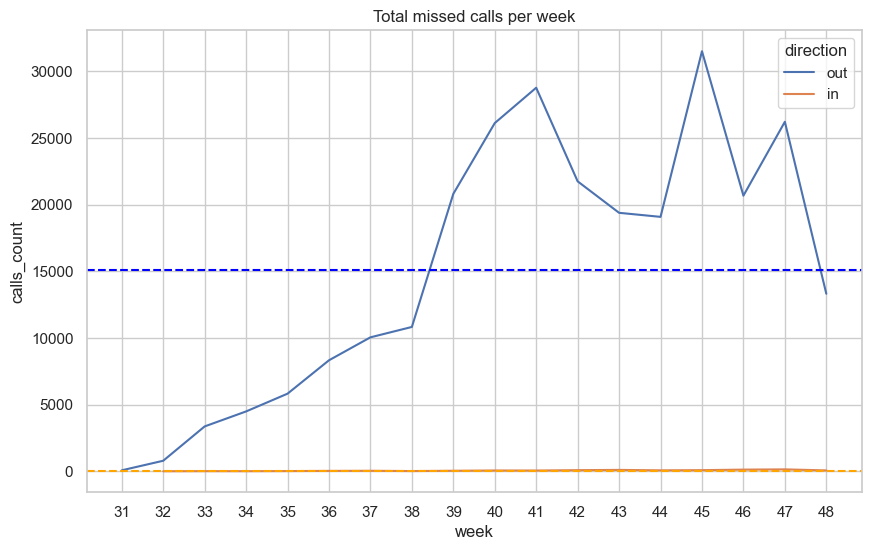

Média semanal geral de chamadas outbound perdidas: 15077.39
Média semanal geral de chamadas inbound perdidas: 51.39


In [96]:
#criação gráfico de linhas
sns.lineplot(data=telecom[telecom['is_missed_call'] == True].groupby(['week', 'direction'])['calls_count'].sum().reset_index(), x='week', y='calls_count', hue='direction')
plt.title('Total missed calls per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=(telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == True)]['calls_count'].sum() / telecom['week'].nunique()), color='orange', linestyle='--')
plt.axhline(y=(telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == True)]['calls_count'].sum() / telecom['week'].nunique()), color='blue', linestyle='--')
plt.show()
print(f"Média semanal geral de chamadas outbound perdidas: {telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == True)]['calls_count'].sum() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de chamadas inbound perdidas: {telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == True)]['calls_count'].sum() / telecom['week'].nunique():.2f}")

O crescimento do volume de chamadas inbound perdidas segue o fluxo linear e esperado, enquanto o fluxo de chamadas outbound perdidas segue um fluxo exponencial.

### Proporção de chamadas inbound perdidas 

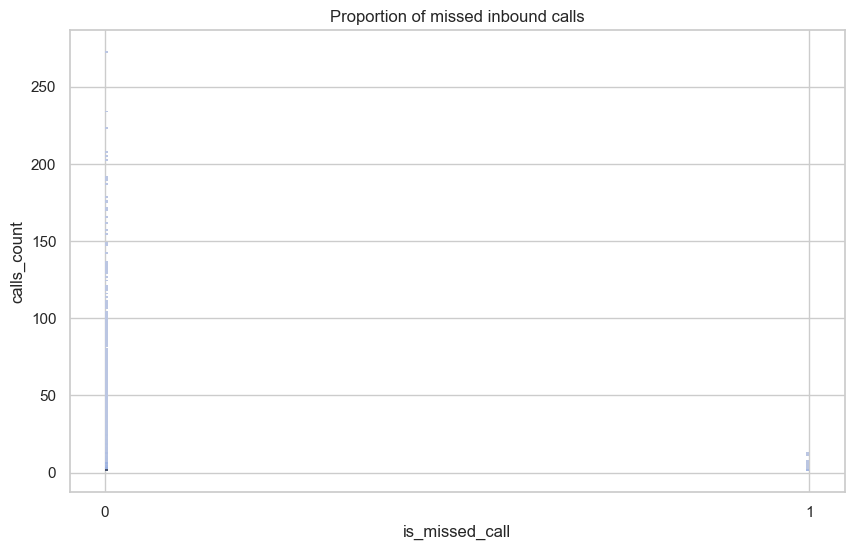

Porcentagem de chamadas inbound atendidas: 99.01%
Porcentagem de chamadas inbound perdidas: 0.99%


In [ ]:
sns.histplot(data=telecom[telecom['direction'] == 'in'], x='is_missed_call', y='calls_count')
plt.title('Proportion of missed inbound calls')
plt.xticks([0,1])
plt.show()
print(f"Porcentagem de chamadas inbound atendidas: {(telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == False)]['calls_count'].sum() / telecom[(telecom['direction'] == 'in')]['calls_count'].sum()) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound perdidas: {(telecom[(telecom['direction'] == 'in') & (telecom['is_missed_call'] == True)]['calls_count'].sum() / telecom[(telecom['direction'] == 'in')]['calls_count'].sum()) * 100:.2f}%")

A proporção de chamadas inbound perdidas são a minoria esmagadora (~1% x ~99%).

### Proporção de chamadas outbound perdidas 

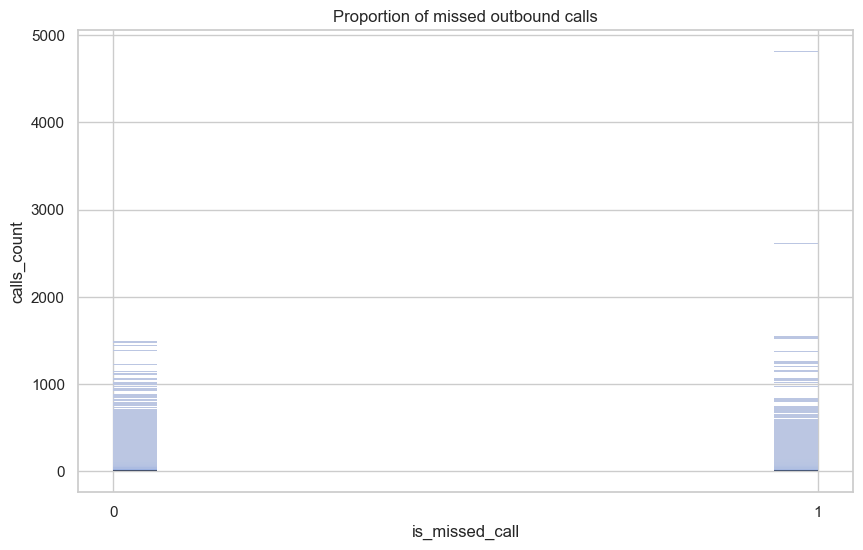

Porcentagem de chamadas inbound atendidas: 55.39%
Porcentagem de chamadas inbound perdidas: 44.61%


In [100]:
# criação histograma
sns.histplot(data=telecom[telecom['direction'] == 'out'], x='is_missed_call', y='calls_count')
plt.title('Proportion of missed outbound calls')
plt.xticks([0, 1])
plt.show()
print(f"Porcentagem de chamadas inbound atendidas: {(telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == False)]['calls_count'].sum() / telecom[(telecom['direction'] == 'out')]['calls_count'].sum()) * 100:.2f}%")
print(f"Porcentagem de chamadas inbound perdidas: {(telecom[(telecom['direction'] == 'out') & (telecom['is_missed_call'] == True)]['calls_count'].sum() / telecom[(telecom['direction'] == 'out')]['calls_count'].sum()) * 100:.2f}%")


A proporção de chamadas outbound perdidas são quase a metade (~45% x ~55%).

### Distribuição tempo de espera

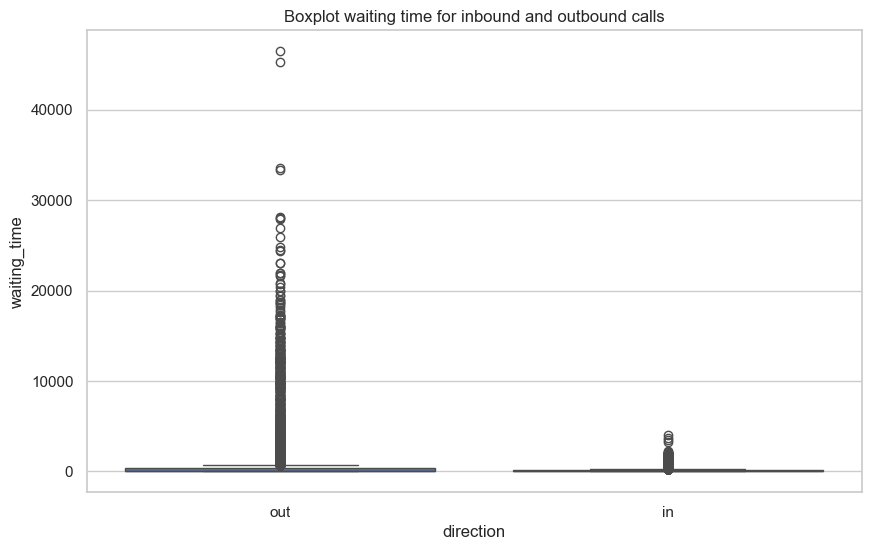

In [43]:
# criação boxplot
sns.boxplot(data=telecom, x='direction', y='waiting_time')
plt.title('Boxplot waiting time for inbound and outbound calls')
plt.show()

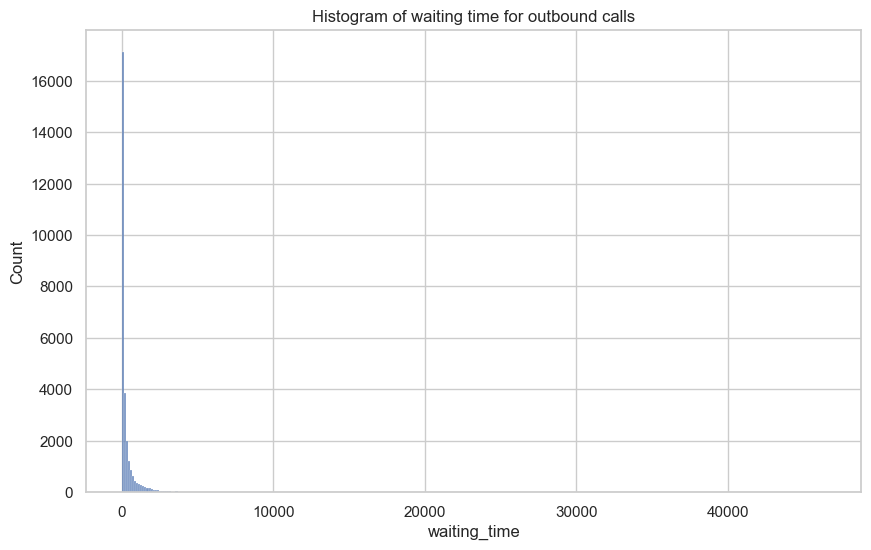

In [44]:
# criação histograma para tempo de espera em chamadas outbound
sns.histplot(data=telecom[telecom['direction'] == 'out']['waiting_time'])
plt.title('Histogram of waiting time for outbound calls')
plt.show()

In [240]:
# aplicação teste de normalidade
stat, p_value = shapiro(telecom['waiting_time'].sample(300))

print(f"p-value: {p_value}")

p-value: 1.0203955674069419e-28


Presença massiva de outliers para chamadas outbound.

### Distribuição contagem de chamadas

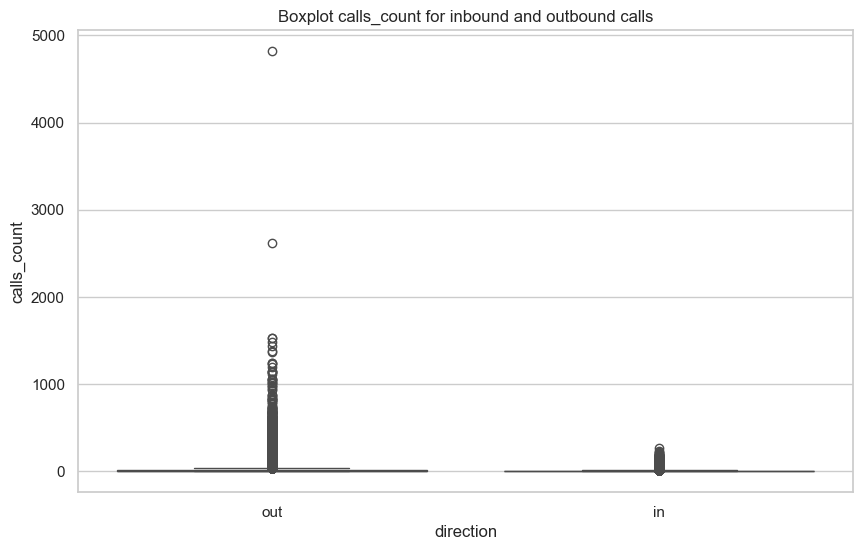

In [109]:
# criação boxplot
sns.boxplot(data=telecom, x='direction', y='calls_count')
plt.title('Boxplot calls_count for inbound and outbound calls')
plt.show()

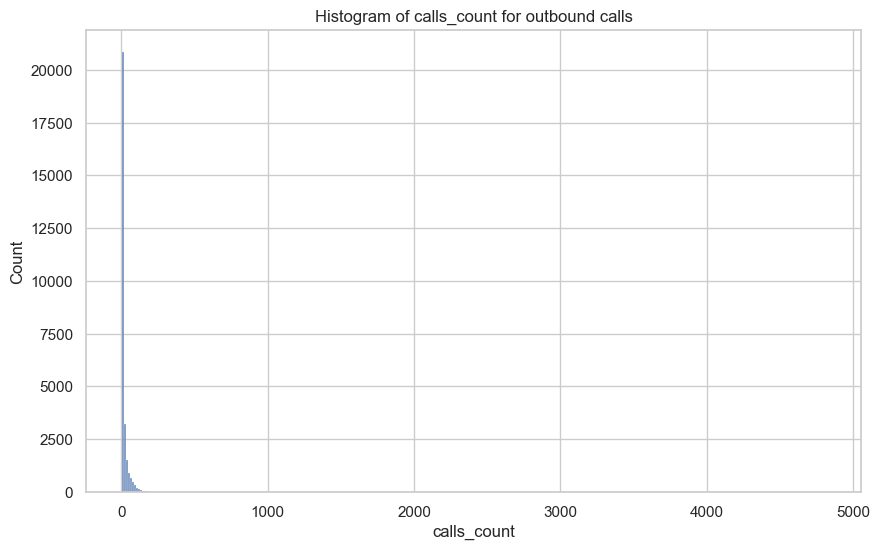

In [110]:
# criação histograma para contagem de chamadas em chamadas outbound
sns.histplot(data=telecom[telecom['direction'] == 'out']['calls_count'])
plt.title('Histogram of calls_count for outbound calls')
plt.show()

In [247]:
# aplicação teste de normalidade
stat, p_value = shapiro(telecom['calls_count'].sample(300))

print(f"p-value: {p_value}")

p-value: 2.828607241371749e-27


Padrãp similar de outliers para chamadas outbound.

### Variação mediana do tempo de espera semanal

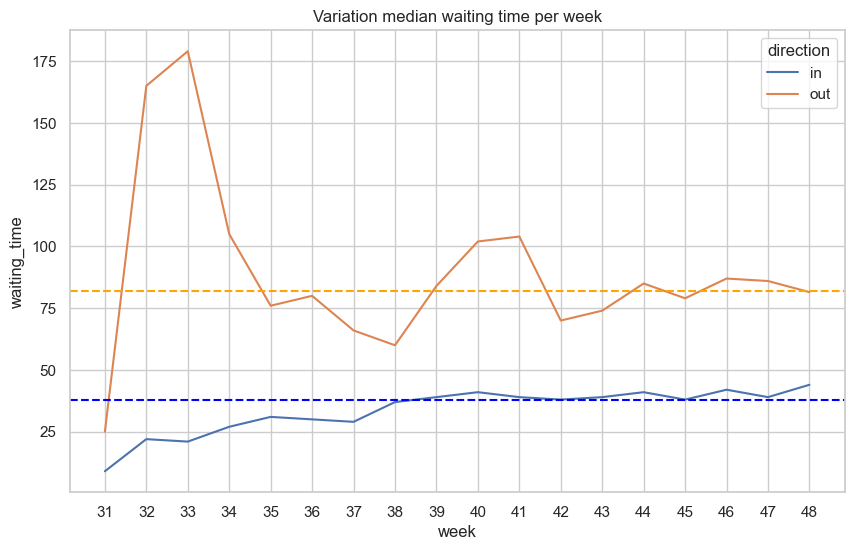

Mediana geral semanal de chamadas outbound: 82.0
Mediana geral semanal de chamadas inbound: 38.0


In [45]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['week', 'direction'])['waiting_time'].median().reset_index(), x='week', y='waiting_time', hue='direction')
plt.title('Variation median waiting time per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=telecom[telecom['direction'] == 'in']['waiting_time'].median(), color='blue', linestyle='--')
plt.axhline(y=telecom[telecom['direction'] == 'out']['waiting_time'].median(), color='orange', linestyle='--')
plt.show()
print(f"Mediana geral semanal de chamadas outbound: {telecom[telecom['direction'] == 'out']['waiting_time'].median()}")
print(f"Mediana geral semanal de chamadas inbound: {telecom[telecom['direction'] == 'in']['waiting_time'].median()}")

A mediana do tempo de espera para chamadas inbound cresceu ao longo do período, enquanto para chamadas outbound teve um pico na primeira semana, seguida por grande queda e seguinte estabilização.

### Variação de operadores trabalhando por semana

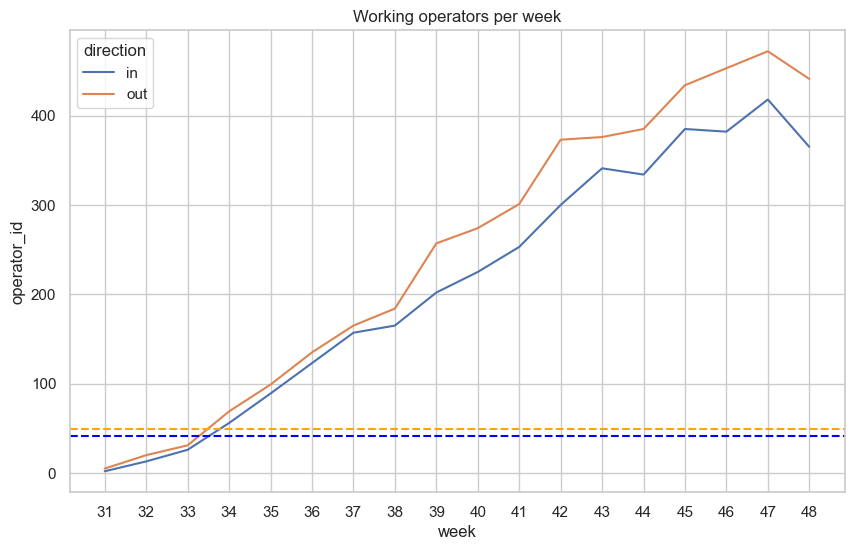

Média semanal geral de operadores trabalhando: 60.67
Média semanal geral de operadores outbound trabalhando: 49.00
Média semanal geral de operadores inbound trabalhando: 41.89


In [46]:
# criação gráfico de linhas
sns.lineplot(data=telecom.groupby(['week', 'direction'])['operator_id'].nunique().reset_index(), x='week', y='operator_id', hue='direction')
plt.title('Working operators per week')
plt.xticks(telecom['week'].unique())
plt.axhline(y=(telecom[telecom['direction'] == 'in']['operator_id'].nunique() / telecom['week'].nunique()), color='blue', linestyle='--')
plt.axhline(y=(telecom[telecom['direction'] == 'out']['operator_id'].nunique() / telecom['week'].nunique()), color='orange', linestyle='--')
plt.show()
print(f"Média semanal geral de operadores trabalhando: {telecom['operator_id'].nunique() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de operadores outbound trabalhando: {telecom[telecom['direction'] == 'out']['operator_id'].nunique() / telecom['week'].nunique():.2f}")
print(f"Média semanal geral de operadores inbound trabalhando: {telecom[telecom['direction'] == 'in']['operator_id'].nunique() / telecom['week'].nunique():.2f}")

Durante todo o período, houve aumento do número de operadores à postos tanto para inbound tanto para outbound.

### Observações gerais

* Pode-se ser notado que houve um crescimento exponencial no volume de chamadas dentro do período analisado (Agosto a Novembro), tanto para inbound e outbound - o aumento do número de operadores à postos seguiu o mesmo ritmo.
* Chamadas outbound representam maioria, cerca de 60%.
* O crescimento das chamadas perdidas foi exponencial apenas para chamadas outbound, enquanto inbound linear.
* Enquanto cerca de 99% das chamadas inbound não são perdidas, para chamadas outbound isso representa cerca de 54%. 

# Cálculo KPIs e Identificação de Ineficiência 

## Definição de KPIs

###  Ratio chamadas inbound perdidas

Será definido como base para análise se um operador perde muitas chamadas inbound um KPI *Missed Rate*, com base em fórmula para comparação de proporções entre operador e equipe (sem o trabalhador):

    total chamadas inbound perdidas do operador / total de chamadas inboud recebidas. 

Critérios que serão utilizados:

    * Diferença estatisticamente significativa (p < 0.05), 
    * Diferença absoluta superior a 5 pontos percentuais, 
    * Diferença relativa de ao menos 25% com relação à equipe

### Mediana tempo de espera

Será definido como base para análise se um operador possui alto tempo de espera para chamadas inbound um KPI baseado em *waiting_time*, com uso da mediana por operador como medida principal, para comparação entre operador e equipe (sem o trabalhador):

Critérios que serão utilizados:

    * Diferença estatisticamente significativa (p < 0.05),
    * Diferença absoluta superior a 30 segundos entre as medianas,
    * Mediana do operador acima do terceiro quartil (Q3) da distribuição da equipe

### Volume mediano semanal de chamadas outbound

Será definido como base para análise se um operador possui baixo volume de chamadas outbound um KPI baseado em dados agregados semanalmente com uso da mediana por operador como medida principal, para comparação entre operador e equipe (sem o trabalhador):

Critérios que serão utilizados:

    * Diferença estatisticamente significativa (p < 0.05),
    * Diferença absoluta superior a 50 chamadas semanais,
    * Diferença relativa do operador pelo menos 30% à equipe.


## Testes Estatísticos

### Alta proporção de chamadas inbound perdidas  

In [47]:
# criação de função para aplicação de teste estatístico a todos os operadores
def test_missed_rate(telecom, min_calls=30, alpha=0.05, min_diff=0.05):
    # filtro inbound 
    data = telecom[telecom['direction'] == 'in'].copy()
    results = []

    # criação de ciclo por usuário
    for user in data['user_id'].unique():
        # filtro operadores com volume mínimo
        user_data = data[data['user_id'] == user]
        counts = user_data['operator_id'].value_counts()
        valid_operators = counts[counts >= min_calls].index
        user_data = user_data[user_data['operator_id'].isin(valid_operators)]
        operators = user_data['operator_id'].unique()

        # criação de ciclo por operador
        for op in operators:
            # segregação total chamadas e total chamadas perdidas operador e dados equipe sem operador
            op_data = user_data[user_data['operator_id'] == op]
            team_data = user_data[user_data['operator_id'] != op]
            operator_calls = op_data.shape[0]
            operator_missed = op_data['is_missed_call'].sum()
            team_calls = team_data.shape[0]
            team_missed = team_data['is_missed_call'].sum()

            # validação
            if operator_calls == 0 or team_calls == 0:
                continue

            # aplicação Two-proportion z-test
            stat, p_value = proportions_ztest([operator_missed, team_missed],[operator_calls, team_calls])
            operator_rate = operator_missed / operator_calls
            team_rate = team_missed / team_calls
            diff = team_rate - operator_rate 
            relative_diff = diff / team_rate

            # decisão baseada em significância, valores absolutos e relativos
            fail = (p_value < alpha) and (diff < -min_diff) and (relative_diff < -0.25)
            results.append({
                'user_id': user,
                'operator_id': op,
                'operator_calls': operator_calls,
                'operator_missed_rate': operator_rate,
                'team_missed_rate': team_rate,
                'diff': diff,
                'relative_diff': relative_diff,
                'p_value': p_value,
                'fail': fail
            })

    df = pd.DataFrame(results)

    # organização final
    df = df.sort_values(by=['fail', 'diff'], ascending=[False, False])

    return df

In [48]:
# aplicação função
results_missed_rate = test_missed_rate(telecom)

In [49]:
# criação função para classificação operadores
def classify_missed(row):
    if row['relative_diff'] < -5:
        return 'crítico '
    elif row['diff'] < -0.15:
        return 'alto'
    else:
        return 'moderado'

In [50]:
# aplicação função
results_missed_rate['classification'] = results_missed_rate.apply(classify_missed, axis=1)

In [51]:
# filtro para operadores que falharam no teste estatístico
results_missed_rate = results_missed_rate[results_missed_rate['fail'] == True]

Foram identificados operadores com taxas significativamente superiores à média da equipe, com destaque para casos extremos onde o desempenho chega a ser até 8–9 vezes pior, indicando potenciais falhas operacionais críticas.

### Mediana alta de períodos de espera inbound

In [52]:
# criação de função para aplicação de teste estatístico a todos os operadores
def test_waiting_time(telecom, min_calls=30, min_samples=10, alpha=0.05, min_diff=30):
    # filtro inbound 
    data = telecom[telecom['direction'] == 'in'].copy()
    results = []

    # criação de ciclo por usuário
    for user in data['user_id'].unique():
        # filtro operadores com volume mínimo
        user_data = data[data['user_id'] == user]
        counts = user_data['operator_id'].value_counts()
        valid_operators = counts[counts >= min_calls].index
        user_data = user_data[user_data['operator_id'].isin(valid_operators)]
        operators = user_data['operator_id'].unique()

        # criação de ciclo por operadores 
        for op in operators:
            # distribuição tempo de espera operador e dados equipe sem operador
            op_data = user_data[user_data['operator_id'] == op]
            team_data = user_data[user_data['operator_id'] != op]
            operator_waiting = op_data['waiting_time']
            team_waiting = team_data['waiting_time']

            # validação 
            if len(operator_waiting) < min_samples or len(team_waiting) < min_samples:
                continue

            # aplicação de teste estatístico Mann Whiteney
            stat, p_value = mannwhitneyu(operator_waiting,team_waiting)
            operator_median = operator_waiting.median()
            team_median = team_waiting.median()
            diff = operator_median - team_median
            user_threshold = user_data['waiting_time'].quantile(0.75)

            # decisão baseada em significância, valores absolutos e relativos
            fail = ((p_value < alpha) and (diff > min_diff) and (operator_median > user_threshold)
)
            results.append({
                'user_id': user,
                'operator_id': op,
                'operator_calls': len(operator_waiting),
                'operator_median_waiting': operator_median,
                'team_median_waiting': team_median,
                'diff_median': diff,
                'team_q3': user_threshold,
                'p_value': p_value,
                'fail': fail
            })

    df = pd.DataFrame(results)

    df = df.sort_values(by=['fail', 'diff_median'], ascending=[False, False])

    return df

In [53]:
# aplicação função
results_waiting_time = test_waiting_time(telecom)

In [54]:
# criação função para classificação dos operadores 
def classify_waiting(row):
    if row['diff_median'] > 200:
        return 'crítico'
    elif row['diff_median'] > 60:
        return 'alto'
    else:
        return 'moderado'

In [55]:
# aplicação função
results_waiting_time['classification'] = results_waiting_time.apply(classify_waiting, axis=1)

In [56]:
# filtro para operadores que falharam no teste estatístico
results_waiting_time = results_waiting_time[results_waiting_time['fail'] == True]

Foram identificados operadores com tempos de espera significativamente superiores ao padrão da equipe, incluindo casos extremos com tempos até 3 vezes maiores, além de padrões recorrentes em determinadas empresas, sugerindo possíveis ineficiências operacionais sistêmicas.

### Volume baixo de chamadas outbound

In [57]:
# criação de função para aplicação de teste estatístico a todos os operadores
def test_outbound_calls(telecom, min_weeks=7, alpha=0.05, min_diff=50):
    # filtro outbound 
    data = telecom[telecom['direction'] == 'out'].copy()
    results = []

    # ciclo por cliente
    for user in data['user_id'].unique():
        user_data = data[data['user_id'] == user]
        # agregação por semana
        weekly_calls = user_data.groupby(['operator_id', 'week'])['calls_count'].sum().reset_index()
        operators = weekly_calls['operator_id'].unique()

        # ciclo por operador
        for op in operators:
            op_data = weekly_calls[weekly_calls['operator_id'] == op]
            team_data = weekly_calls[weekly_calls['operator_id'] != op]
            operator_outbound = op_data['calls_count']
            team_outbound = team_data['calls_count']

            # validação 
            if len(operator_outbound) < min_weeks or len(team_outbound) < min_weeks:
                continue

            # aplicação teste estatístico
            stat, p_value = mannwhitneyu(operator_outbound,team_outbound)
            operator_median = operator_outbound.median()
            team_median = team_outbound.median()
            diff = operator_median - team_median  
            relative_diff = diff / team_median

            # decisão baseada em significância, valores absolutos e relativos
            fail = ((p_value < alpha) and (relative_diff < -0.3) and (diff < -min_diff))

            results.append({
                'user_id': user,
                'operator_id': op,
                'weeks_observed': len(operator_outbound),
                'operator_median_weekly_outbound': operator_median,
                'team_median_weekly_outbound': team_median,
                'diff_median': diff,
                'relative_diff': relative_diff,
                'p_value': p_value,
                'fail': fail
            })

    df = pd.DataFrame(results)

    df = df.sort_values(by=['fail', 'diff_median'], ascending=[False, True])

    return df

In [58]:
# aplicação função
results_outbound_calls = test_outbound_calls(telecom)

In [59]:
# criação função para classificação de operadores
def classify_outbound(row):
    if row['relative_diff'] < -0.9:
        return 'crítico'
    elif row['relative_diff'] < -0.7:
        return 'alto'
    else: 
        return 'moderado'

In [60]:
# aplicação função
results_outbound_calls['classification'] = results_outbound_calls.apply(classify_outbound, axis=1)

In [61]:
# filtro para operadores que falharam no teste estatístico
results_outbound_calls = results_outbound_calls[results_outbound_calls['fail']== True]


In [62]:
results_outbound_calls

,user_id,operator_id,weeks_observed,operator_median_weekly_outbound,team_median_weekly_outbound,diff_median,relative_diff,p_value,fail,classification
160,167827,929424.00,9,68.00,1766.00,-1698.00,-0.96,0.01,True,crítico
8,166406,879896.00,16,11.50,333.00,-321.50,-0.97,0.00,True,crítico
155,167650,921306.00,10,53.50,222.00,-168.50,-0.76,0.00,True,alto
84,167035,923528.00,10,38.50,203.00,-164.50,-0.81,0.01,True,alto
23,166511,891416.00,14,52.00,184.00,-132.00,-0.72,0.00,True,alto
0,166377,880022.00,14,6.50,131.50,-125.00,-0.95,0.00,True,crítico
56,166782,899250.00,14,96.00,174.00,-78.00,-0.45,0.01,True,moderado
104,167150,905570.00,12,5.00,83.00,-78.00,-0.94,0.00,True,crítico
105,167150,905574.00,13,24.00,83.00,-59.00,-0.71,0.02,True,alto
28,166536,900194.00,10,1.50,53.00,-51.50,-0.97,0.00,True,crítico


Foram identificados operadores com volume de chamadas semanais outbound significativamente inferiores ao padrão da equipe, incluindo casos extremos com desempenho até 97% inferior à equipe. 

## Observações gerais

### Missed Rate

In [63]:
results_missed_rate

,user_id,operator_id,operator_calls,operator_missed_rate,team_missed_rate,diff,relative_diff,p_value,fail,classification
33,166983,901880.00,106,0.09,0.01,-0.08,-8.91,0.00,True,crítico
100,168187,948286.00,37,0.14,0.05,-0.09,-1.75,0.02,True,moderado
84,168187,937956.00,59,0.14,0.05,-0.09,-1.93,0.00,True,moderado
55,167264,919554.00,75,0.15,0.02,-0.13,-8.39,0.01,True,crítico
45,167071,913942.00,85,0.33,0.17,-0.16,-0.95,0.02,True,alto


Operador 913942 -> 
    O operador perde cerca de 33% das chamadas recebidas e possui uma taxa de chamadas perdidas quase 2x superior aos padrões da equipe. Destaca-se o impacto operacional em volume, dado o número significativo de chamadas (85). O padrão observado sugere um problema consistente de desempenho, com impacto direto na capacidade de atendimento.

Operador 919554 -> 
    O operador perde cerca de 15% das chamadas recebidas e possui uma taxa de chamadas perdidas quase 9x superior aos padrões da equipe. Diferença extrema. Indicação de comportamento altamente discrepante em relação ao padrão operacional.

Operador 901880 -> 
    O operador perde cerca de 9% das chamadas recebidas e possui uma taxa de chamadas perdidas quase 10x superior à equipe. Diferença extrema. O volume de chamadas (106) amplifica o impacto total, tornando este um dos casos mais relevantes em termos operacionais. O desvio extremo em relação à equipe sugere um padrão consistente de ineficiência.

Operador 937956 e 948286 ->
    Os operadores perdem cerca de 14% das chamadas recebidas e possui uma taxa de chamadas perdidas quase 3x superior à equipe. Diferença alta. A similaridade entre os resultados, associada ao fato de pertencerem à mesma empresa (user_id 168187), sugere a presença de um padrão coletivo. Esse comportamento pode indicar ineficiência operacional sistêmica, como problemas de distribuição de chamadas, dimensionamento de equipe ou processos internos, em vez de falhas estritamente individuais.

### Tempo de Espera 

In [64]:
results_waiting_time

,user_id,operator_id,operator_calls,operator_median_waiting,team_median_waiting,diff_median,team_q3,p_value,fail,classification
29,166916,906406.00,45,390.00,132.00,258.00,347.75,0.00,True,crítico
92,168187,937736.00,34,108.00,43.00,65.00,83.00,0.00,True,alto
90,168187,937752.00,38,94.00,43.00,51.00,83.00,0.00,True,moderado
86,168187,937760.00,35,84.00,43.00,41.00,83.00,0.00,True,moderado
100,168187,948286.00,37,84.00,44.00,40.00,83.00,0.01,True,moderado


Operador -> 906406
    Mediana do tempo de espera do operador é quase 3x superior à equipe sem ele. O padrão observado sugere um problema consistente de desempenho, com impacto direto na capacidade de atendimento. 

Operador 937736, 937752, 937760 e 948286 ->
    Mediana do tempo de espera do operador é quase 2x superior à equipe sem ele. A similaridade entre os resultados, associada ao fato de pertencerem à mesma empresa (user_id 168187), sugere a presença de um padrão coletivo.

### Chamadas Outbound

In [65]:
results_outbound_calls

,user_id,operator_id,weeks_observed,operator_median_weekly_outbound,team_median_weekly_outbound,diff_median,relative_diff,p_value,fail,classification
160,167827,929424.00,9,68.00,1766.00,-1698.00,-0.96,0.01,True,crítico
8,166406,879896.00,16,11.50,333.00,-321.50,-0.97,0.00,True,crítico
155,167650,921306.00,10,53.50,222.00,-168.50,-0.76,0.00,True,alto
84,167035,923528.00,10,38.50,203.00,-164.50,-0.81,0.01,True,alto
23,166511,891416.00,14,52.00,184.00,-132.00,-0.72,0.00,True,alto
0,166377,880022.00,14,6.50,131.50,-125.00,-0.95,0.00,True,crítico
56,166782,899250.00,14,96.00,174.00,-78.00,-0.45,0.01,True,moderado
104,167150,905570.00,12,5.00,83.00,-78.00,-0.94,0.00,True,crítico
105,167150,905574.00,13,24.00,83.00,-59.00,-0.71,0.02,True,alto
28,166536,900194.00,10,1.50,53.00,-51.50,-0.97,0.00,True,crítico


Grupo 1 (929424, 879896, 894662, 903312, 880022, 944764, 905570, 900194) ->
    Os operadores apresentam volumes semanais extremamente reduzidos de chamadas outbound. Em alguns casos, a diferença ultrapassa 90% em termos relativos, indicando ausência quase total de atividade outbound em comparação com o padrão operacional.
    Esse comportamento sugere uma desconexão significativa com a função esperada. Pode indicar ausência de atribuição de chamadas ou função distinta dentro da operação, além de possível baixa produtividade individual.

Grupo 2 (945298, 902742, 899250, 921306, 923528, 921320, 891416, 916424, 905574) -> 
    Os operadores apresentam volumes semanais de chamadas inferiores à equipe, com diferenças relativas entre 40% e 80%. Esses operadores mantêm atividade outbound em níveis significativamente abaixo do esperado, sugerindo menor produtividade individual. O padrão indica possível ineficiência na execução ou menor ritmo operacional em comparação com a equipe.


# Conclusão e Recomendações de Negócio

## Resultados gerais

### Operadores com ineficiência individual relevante

Foram identificados operadores com desempenho significativamente inferior em indicadores de chamadas inbound.

Destaca-se o operador 948286, que apresenta simultaneamente alta taxa de chamadas perdidas (~14%) e tempos de espera elevados, configurando o caso mais consistente de ineficiência individual.

Adicionalmente, operadores como 913942 e 901880 demonstram elevado impacto operacional no indicador de chamadas perdidas, seja pela magnitude da diferença absoluta (+16 p.p.) ou pelo volume de chamadas processadas, amplificando o impacto total na operação.

Esses casos indicam falhas consistentes na capacidade de atendimento.

A análise de chamadas outbound identificou operadores com atividade extremamente reduzida, em alguns casos mais de 90% inferior ao padrão da equipe.

Esse comportamento indica ausência prática de atuação outbound, podendo estar relacionado a fatores operacionais ou a baixa produtividade individual.

Foram também identificados operadores com atividade outbound consistente, porém inferior ao padrão da equipe, com reduções entre 40% e 80%.

Esses casos indicam menor produtividade individual, sem evidência de ausência total de atividade.

### Padrões sistêmicos por empresa

Foram identificados padrões recorrentes de baixo desempenho concentrados em determinadas empresas.

Destaca-se o caso da empresa 168187, onde múltiplos operadores (937956, 948286, 937736, 937752, 937760) apresentam simultaneamente:

* taxas elevadas de chamadas perdidas
* tempos de espera superiores ao padrão da equipe

A consistência dos resultados sugere a presença de ineficiências estruturais, possivelmente relacionadas à distribuição de chamadas, dimensionamento da equipe ou processos operacionais.

### Diferença entre impacto absoluto e relativo

Observou-se que alguns operadores apresentam diferenças extremas em termos relativos, mesmo com taxas absolutas moderadas.

Por outro lado, operadores com diferenças absolutas elevadas e alto volume de chamadas tendem a gerar maior impacto operacional.

Essa distinção é fundamental para priorização de ações, uma vez que nem todos os desvios estatísticos representam o mesmo impacto no negócio.

## Recomendações

### Operadores

Agentes que reprovaram em 2 ou mais testes devem ser priorizados para medidas corretivas como treinamento e acompanhament.

Agentes que reprovaram isoladamente devem receber num primeiro momento orientações mais específicas para dado o seu contexto.

### Clientes

Investigação minuciosa de empresas com padrões recorrentes de ineficiência para identificar possíveis problemas de distribuição de chamadas, dimensionamento de equipe ou processos internos.